###############################################################################################

##### Membres du Groupe : 

- FOGUE FEUSSI Franck Jorel
- Tasnim BENALLAL
- Victoria VIDAL

###############################################################################################

### EXPLICATION DU PROBLEME DE MACHINE LEARNING

Dans un environnement numérique de plus en plus saturé par la publicité en ligne, il devient essentiel pour les entreprises de pouvoir anticiper la performance de leurs campagnes publicitaires. Pour les petites entreprises en particulier, une mauvaise allocation du budget publicitaire peut avoir un impact significatif sur leur rentabilité.

C’est dans ce contexte qu’intervient Adbot, une plateforme qui accompagne les petites entreprises africaines dans la gestion et l’optimisation de leurs campagnes publicitaires numériques. L’objectif de ce projet est de répondre à la question suivante :
**peut-on prédire le succès futur d’une publicité numérique ?**

Plus précisément, le défi consiste ici à prédire le nombre de clics qu’une publicité recevra dans une semaine ( j+7) *(Nous sommes allé un peu plus loin en élargissant l'horizon de prédiction : nous avons donc prédit à 1, 2 et 3 semaines)*. En marketing digital, un clic correspond au moment où un utilisateur voit une publicité et interagit avec celle-ci en cliquant sur un lien. Le nombre de clics est donc un indicateur clé de l’engagement des utilisateurs et de l’efficacité d’une campagne publicitaire.

Résoudre ce problème présente un fort potentiel : des prédictions fiables du nombre de clics permettent aux entreprises d’optimiser leurs stratégies marketing, d’allouer efficacement leurs ressources publicitaires et de maximiser le retour sur investissement. En fournissant des recommandations basées sur les données, Adbot contribue ainsi à améliorer l’engagement client et à soutenir la croissance des petites entreprises.

### PRESENTATION DU JEU DE DONNEES

Les données proviennent de 185 clients de la plateforme Adbot et regroupent des enregistrements publicitaires quotidiens. les variables sont les suivantes :

| Variable | Description |
|----------|-------------|
| clicks (target) | Nombre de clics sur la publicité|
| impressions | Nombre de fois où la publicité a été affichée |
| cost | Montant dépensé pour diffuser la publicité |
| conversions | Nombre d’actions finales (achat, inscription, formulaire, etc.) |
| impression_share | Pourcentage des impressions réellement obtenues par rapport au maximum possible |
| conversions_calls | Nombre de conversions issues spécifiquement d’appels téléphoniques|
| ad_type | Type de publicité |
| headline1_len, headline2_len | Longueur des titres (nombre de caractères) |
| ad_description_len | Longueur du texte descriptif |
| date | Date de diffusion ou d’observation|
| start_time / end_time | Heure de début et de fin d’appel |
| duration| Durée d’un appel |
| call_type | Type d’appel|
| currency | Devise utilisée pour le coût (USD, XAR) |
| ID| Identifiant unique (client) |

**Approche Méthodologique**

1. **Importation et Nettoyage des données**
2. **Exploration des données** : visualisation de l'évolution des clics, impressions et coûts dans le temps ; analyse par devise et type de publicité ; détection de tendances et saisonnalité
3. **Feature Engineering** : création de features temporelles (jour, mois, jour de semaine, jours fériés), encodage des variables catégorielles, calcul de lags et différences, statistiques par semaine/mois
4. **Modélisation** : comparaison de plusieurs algorithmes (LightGBM, XGBoost, RandomForest) avec validation temporelle
5. **Évaluation** : calcul du RMSE ; analyse des importances de features pour l'interprétabilité

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

### 1. Importation et nettoyage des données

In [45]:
# Importation des données
df = pd.read_csv("../data/Train_clicks.csv")
df.info()

# Plage de dates et nombre de jours
print(f"\nPlage de dates: {df['date'].min()} à {df['date'].max()}")
print(f"Nombre de jours couverts au total: {(pd.to_datetime(df['date']).max() - pd.to_datetime(df['date']).min()).days + 1}")

<class 'pandas.DataFrame'>
RangeIndex: 289926 entries, 0 to 289925
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   impressions         289526 non-null  float64
 1   clicks              289526 non-null  float64
 2   cost                289526 non-null  float64
 3   conversions         289526 non-null  float64
 4   ad_type             289526 non-null  str    
 5   currency            289526 non-null  str    
 6   ID                  289926 non-null  str    
 7   date                289926 non-null  str    
 8   call_type           36900 non-null   str    
 9   call_status         36900 non-null   str    
 10  start_time          36900 non-null   str    
 11  duration            36900 non-null   float64
 12  end_time            36900 non-null   str    
 13  display_location    36900 non-null   str    
 14  impression_share    289926 non-null  float64
 15  conversions_calls   280071 non-null  float64


In [31]:
# On supprime les observations pour lesquelles la target est manquante
df_train = df[~df["clicks"].isna()].copy()
df_train.reset_index(drop=True, inplace=True)

# conversion en format date
df_train['date'] = pd.to_datetime(df_train['date'])

# Delete des colonnes qui ont trop de valeurs manquantes
df_train.drop(['call_type', 'call_status', 'start_time', 'duration', 'end_time', 'display_location', 'conversions_calls',
                'conversions'], axis=1, inplace=True)

# # Étape 4 : On détecte les doublons
# ''' 2 types de doublons : 
# - Doublons partiels (même ID et date) - NORMAL : plusieurs annonces par client le même jour
# - Doublons complets (ligne entièrement dupliquée) - À SUPPRIMER 
# '''
# doublons_id_date = df_train.duplicated(subset=['ID', 'date']).sum()
# print(f"\nDoublons partiels (ID, date): {doublons_id_date}")

# doublons_complets = df_train.duplicated(keep=False).sum()
# print(f"\nDoublons complets: {doublons_complets}")

# # On supprime les doublons complets
# if doublons_complets > 0:
#     df_train = df_train.drop_duplicates(keep='first').reset_index(drop=True)
#     print(f"Nouvelles dimensions: {df_train.shape[0]} lignes, {df_train.shape[1]} colonnes")

In [32]:
display(df_train.shape)
display(df_train.tail())
df_train.head()

(289526, 11)

,impressions,clicks,cost,ad_type,currency,ID,date,impression_share,headline1_len,headline2_len,ad_description_len
289521,299.0,29.0,6809.716151,RESPONSIVE_SEARCH_AD,ZAR,ID_65b0f65c7fe62e56c5593d55,2024-02-13,9.99,1.0,5.0,13.0
289522,410.0,28.0,6598.474957,RESPONSIVE_SEARCH_AD,ZAR,ID_65b0f65c7fe62e56c5593d55,2024-02-13,9.99,1.0,4.0,16.0
289523,281.0,11.0,3642.348176,RESPONSIVE_SEARCH_AD,ZAR,ID_65b0f65c7fe62e56c5593d55,2024-02-13,9.99,1.0,4.0,14.0
289524,41.0,5.0,547.477180,EXPANDED_DYNAMIC_SEARCH_AD,ZAR,ID_65b0f65c7fe62e56c5593d55,2024-02-13,9.99,0.0,0.0,0.0
289525,77.0,1.0,394.983536,RESPONSIVE_SEARCH_AD,ZAR,ID_65b0f65c7fe62e56c5593d55,2024-02-13,9.99,1.0,4.0,13.0


,impressions,clicks,cost,ad_type,currency,ID,date,impression_share,headline1_len,headline2_len,ad_description_len
0,142.0,15.0,3393.0,EXPANDED_TEXT_AD,ZAR,ID_5da86e71bf5dee4cf5047046,2020-01-01,16.279669,2.0,5.0,11.0
1,89.0,8.0,1817.0,EXPANDED_TEXT_AD,ZAR,ID_5da86e71bf5dee4cf5047046,2020-01-01,16.279669,2.0,2.0,13.0
2,59.0,8.0,1743.0,EXPANDED_TEXT_AD,ZAR,ID_5da86e71bf5dee4cf5047046,2020-01-01,16.279669,2.0,2.0,10.0
3,78.0,4.0,917.0,EXPANDED_TEXT_AD,ZAR,ID_5da86e71bf5dee4cf5047046,2020-01-01,16.279669,2.0,3.0,13.0
4,20.0,1.0,217.0,EXPANDED_TEXT_AD,ZAR,ID_5da86e71bf5dee4cf5047046,2020-01-01,16.279669,2.0,2.0,13.0


### 2. Analyse Exploratoire

Cette section explore en profondeur la structure et les caractéristiques des données :

In [33]:
# Liste des colonnes restantes après le nettoyage
df_train.columns

Index(['impressions', 'clicks', 'cost', 'ad_type', 'currency', 'ID', 'date',
       'impression_share', 'headline1_len', 'headline2_len',
       'ad_description_len'],
      dtype='str')

#### 2.1. Statistiques Descriptives et Couverture des données

In [34]:
# Statistiques descriptives complètes
display(df_train.describe().T)

,count,mean,min,25%,50%,75%,max,std
impressions,289526.0,72.80962,0.0,6.0,23.0,69.0,6833.0,153.592792
clicks,289526.0,8.039927,0.0,0.0,2.0,6.0,4227.0,36.241161
cost,289526.0,2208.525051,0.0,0.0,553.0,2062.5,719928.0,7392.609733
date,289526,2022-10-06 16:21:35.336515,2020-01-01 00:00:00,2022-02-04 00:00:00,2022-11-12 00:00:00,2023-07-21 00:00:00,2024-02-13 00:00:00,NaN
impression_share,289526.0,16.672673,5.0,9.99,11.430056,20.135137,100.0,12.180109
headline1_len,289526.0,2.745584,0.0,2.0,3.0,4.0,7.0,1.571108
headline2_len,289526.0,2.879824,0.0,1.0,3.0,4.0,7.0,1.670356
ad_description_len,289526.0,10.706165,0.0,10.0,12.0,14.0,20.0,4.50945


Nombre de clients uniques: 185

Observations par client (statistiques):
  Min: 19
  Max: 1467
  Mean: 365.23
  Median: 204.00


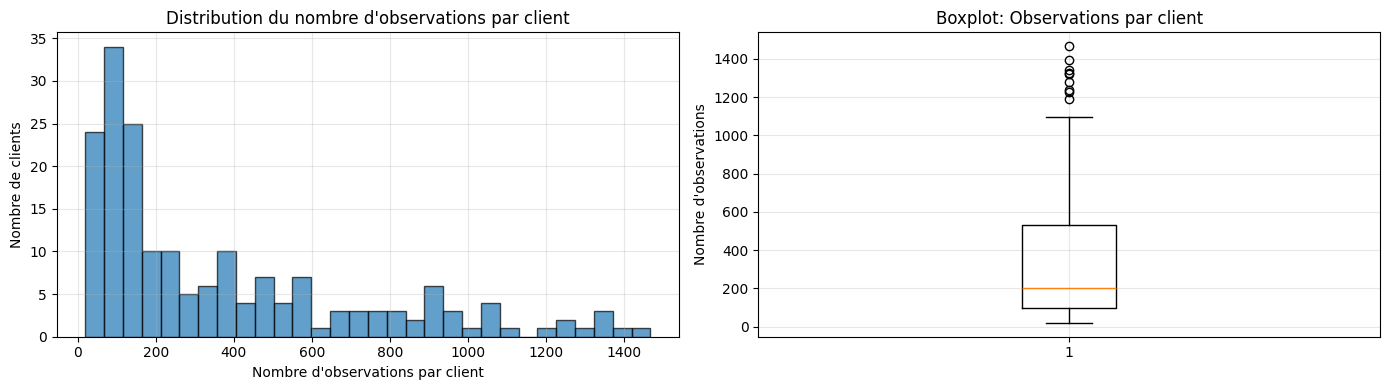

In [43]:
# On analyse des clients uniques et leurs couverture temporelle
df_nclient = df_train.groupby(["date", "ID"]).size().reset_index(name="count")
n_clients = df_nclient['ID'].nunique()
print(f"Nombre de clients uniques: {n_clients}")

# Statistiques du nombre d'observations par client
obs_per_client = df_nclient.groupby('ID').size()
print(f"\nObservations par client (statistiques):")
print(f"  Min: {obs_per_client.min()}")
print(f"  Max: {obs_per_client.max()}")
print(f"  Mean: {obs_per_client.mean():.2f}")
print(f"  Median: {obs_per_client.median():.2f}")

# Graphe de distribution par client selon le nombre d'observation (nombre de dates)
plt.figure(figsize=(14, 4))
plt.subplot(1, 2, 1)
plt.hist(obs_per_client, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel("Nombre d'observations par client")
plt.ylabel("Nombre de clients")
plt.title("Distribution du nombre d'observations par client")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(obs_per_client)
plt.ylabel("Nombre d'observations")
plt.title("Boxplot: Observations par client")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

On a des séries temporelles de longueurs inégales. La majorité des clients ont une faible profondeur historique (Concentration forte entre ~20 et 200 observations/dates)

#### 2.2. Distributions univariées

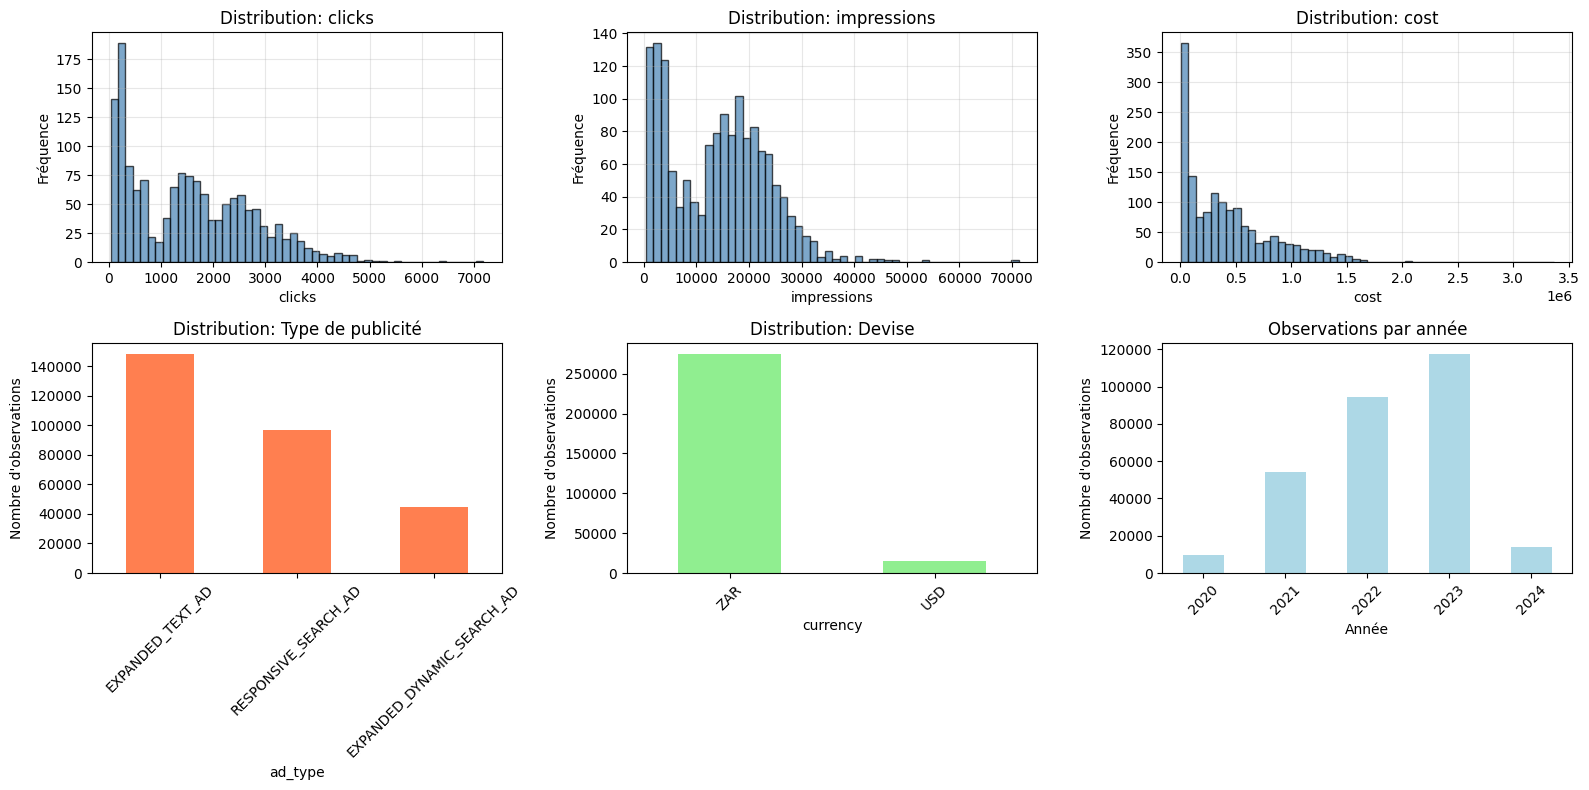

In [ ]:
# Distributions univariées (histogrammes)
df_dist_uni = df_train.groupby(['date']).agg({
        'impressions': 'sum',
        'clicks': 'sum',
        'cost' : 'sum',
    }).reset_index()
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
numeric_cols = ['clicks', 'impressions', 'cost']

# Histogrammes des variables numériques
for i, col in enumerate(numeric_cols):
    ax = axes[0, i]
    ax.hist(df_dist_uni[col], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel('Fréquence')
    ax.set_title(f"Distribution: {col}")
    ax.grid(True, alpha=0.3)

# Distributions des variables catégorielles
ax = axes[1, 0]
df_train['ad_type'].value_counts().plot(kind='bar', ax=ax, color='coral')
ax.set_title("Distribution: Type de publicité")
ax.set_ylabel("Nombre d'observations")
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

ax = axes[1, 1]
df_train['currency'].value_counts().plot(kind='bar', ax=ax, color='lightgreen')
ax.set_title("Distribution: Devise")
ax.set_ylabel("Nombre d'observations")
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# Observations par année (si elle existe après nettoyage)
try:
    df_train['year_temp'] = pd.to_datetime(df_train['date']).dt.year
    ax = axes[1, 2]
    df_train['year_temp'].value_counts().sort_index().plot(kind='bar', ax=ax, color='lightblue')
    ax.set_title("Observations par année")
    ax.set_ylabel("Nombre d'observations")
    ax.set_xlabel("Année")
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
except:
    pass

plt.tight_layout()
plt.show()

#### 2.3. Analyse temporelle

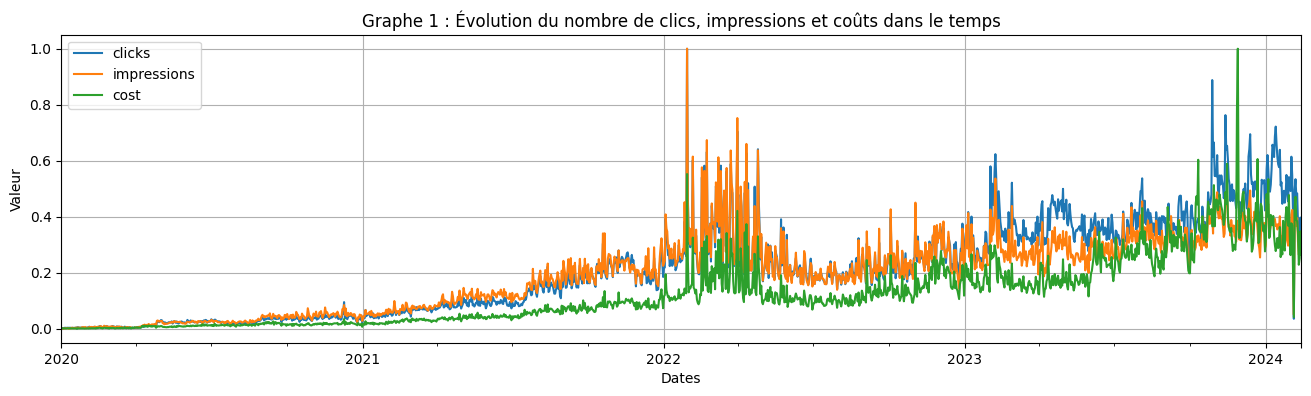

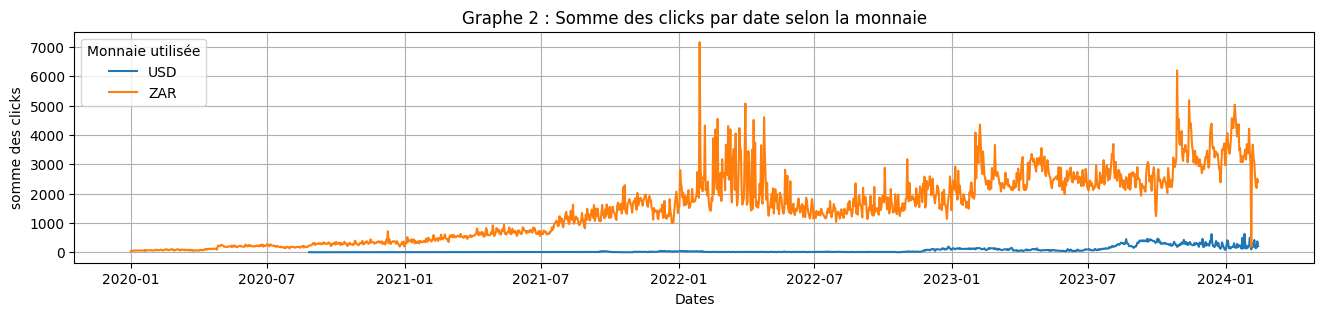

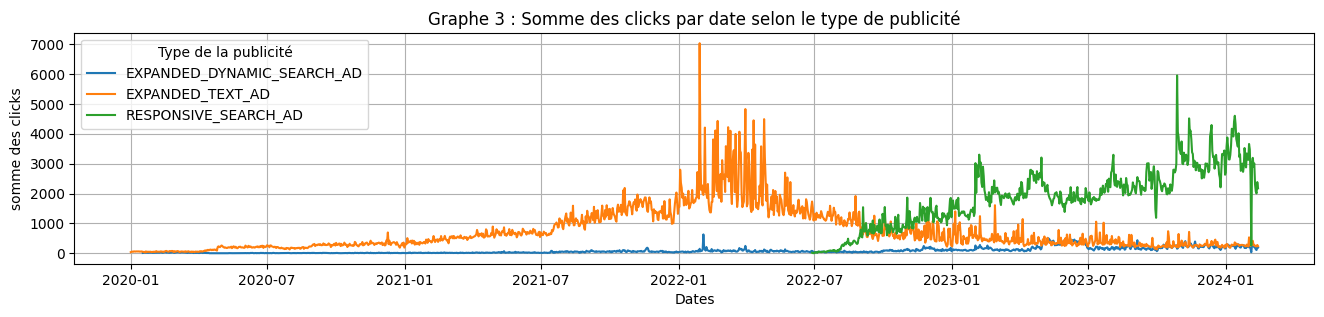

In [54]:
# Graphe de l'évolution dans le temps du nombre de clics, impressions et coûts sur publicités fait par les clients
df_sum_clicks = df_train.groupby(['date'])[['clicks', 'impressions', 'cost']].sum().reset_index()
cols = ['clicks', 'impressions', 'cost']
df_sum_clicks[cols] = (df_sum_clicks[cols] - df_sum_clicks[cols].min()) / (df_sum_clicks[cols].max() - df_sum_clicks[cols].min())
df_sum_clicks.plot( x='date',  y=cols,  figsize=(16, 4))
plt.xlabel('Dates')
plt.ylabel('Valeur')
plt.title('Graphe 1 : Évolution du nombre de clics, impressions et coûts dans le temps')
plt.legend()
plt.grid(True)
plt.show()

# Graphe de l'évolution dans le temps du nombre de clics sur publicités fait par les clients selon la monnaie utilisée
df_sum_clicks_currency = df_train.groupby(['currency', 'date'])['clicks'].sum().reset_index()
plt.figure(figsize=(16,3))
sns.lineplot(data=df_sum_clicks_currency, x='date', y='clicks', hue='currency')
plt.xlabel("Dates")
plt.ylabel('somme des clicks')
plt.title('Graphe 2 : Somme des clicks par date selon la monnaie')
plt.legend(title='Monnaie utilisée')
plt.grid(True)
plt.show()

# Graphe de l'évolution dans le temps du nombre de clics sur publicités fait par les clients selon le type de publicité
df_sum_clicks_par_ad = df_train.groupby(['ad_type', 'date'])['clicks'].sum().reset_index()
plt.figure(figsize=(16,3))
sns.lineplot(data=df_sum_clicks_par_ad, x='date', y='clicks', hue='ad_type')
plt.xlabel("Dates")
plt.ylabel('somme des clicks')
plt.title('Graphe 3 : Somme des clicks par date selon le type de publicité')
plt.legend(title='Type de la publicité')
plt.grid(True)
plt.show()

1. **Graphique 1**
 - On note une tendance globale fortement croissante des trois (03) métriques entre 2020 et 2024. Avec la digitalisation croissante, de plus en plus d'entreprises déplacent leurs efforts marketing vers le numérique, d'où l'augmentation des investissements publicitaires en ligne et ainsi la hausse du nombres de clics.
 - On remarque aussi qu'il y'a 3 phases dans la série des clics : 
   * *2020 - mi 2021* : niveau faible mais en croissance progressive
   * *fin 2021 - début 2022* : forte hausse et grande volatilité (pics très marqués allant jusqu'en 7000 clics)
   * *mi 2022 - 2024* : Stabilisation toujours avec tendance croissante, mais avec des fluctuations plus modérées

2. **Graphique 2**
 - La quasi-totalité des clics provient de la monnaie ZAR.
 - La courbe USD est très basse sur toute la période, avec une légère hausse fin 2023.
 - Les pics observés dans le graphe 1 sont presque exclusivement dus à ZAR.

3. **Graphique 3**
 - *EXPANDED_TEXT_AD* :
   * dominant jusqu’à mi-2022
   * chute progressive ensuite

 - *RESPONSIVE_SEARCH_AD* :
   * apparaît vers mi-2022
   * croissance rapide et devient le format dominant en 2023–2024
  Il semblerait qu'il y' ait un changement structurel de stratégie publicitaire avec l'abandon progressive des EXPANDED_TEXT_AD et l'adoption massive des RESPONSIVE_SEARCH_AD. Le type de publicité influence donc le niveau des clics.

 - *EXPANDED_DYNAMIC_SEARCH_AD* :
   * contribution très faible sur toute la période

#### 2.3.1. Analyse de saisonnalité

Examen de l'évolution journalière des clics par année et par mois pour identifier les patterns saisonniers et variations cycliques.

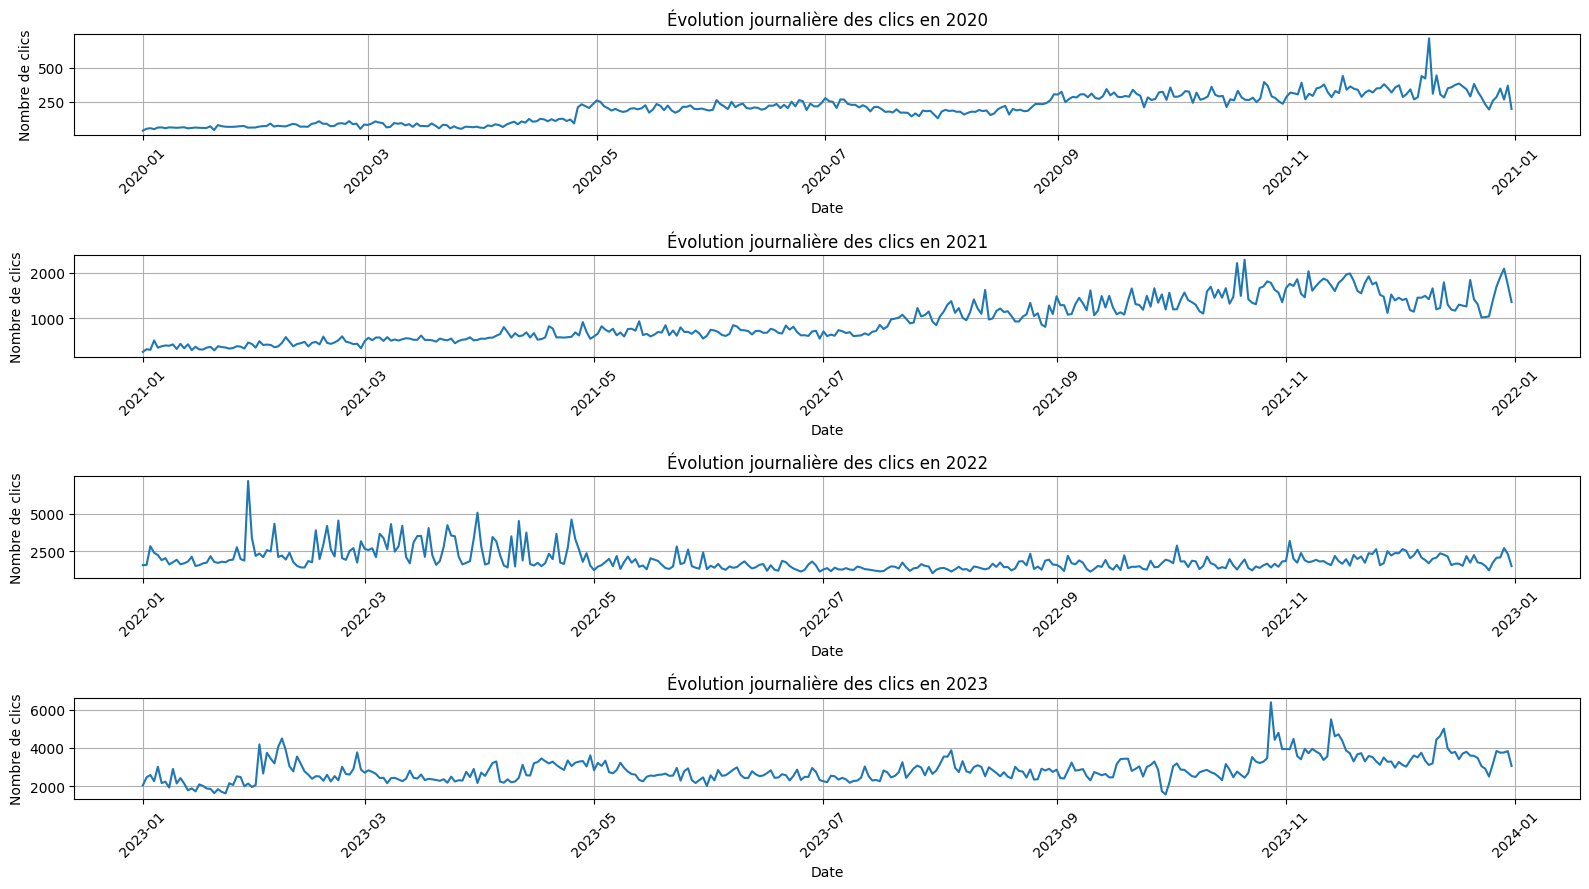

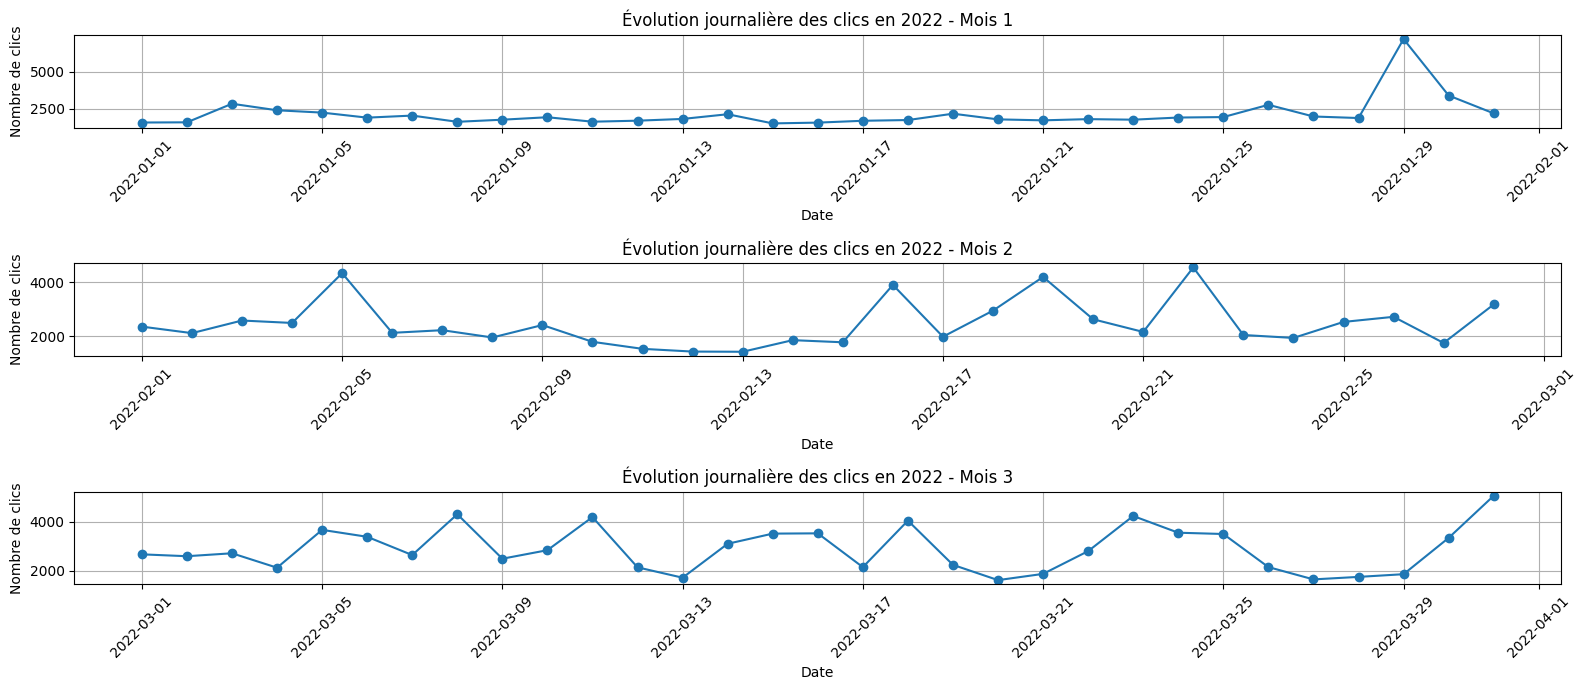

In [55]:
#### Evolution des clics (zoom sur les années et les mois pour voir s'il y'a une saisonnalité) ###################""

## Pour les années 2020, 2021, 2022 et 2023
annees = [2020, 2021, 2022, 2023]
plt.figure(figsize=(16, 9))  # 3 graphiques verticalement

for i, annee in enumerate(annees, 1):
    df_year = df_train[df_train['date'].dt.year == annee]
    daily_clicks = df_year.groupby('date')['clicks'].sum()
    
    plt.subplot(len(annees), 1, i)
    plt.plot(daily_clicks.index, daily_clicks.values)
    plt.title(f"Évolution journalière des clics en {annee}")
    plt.xlabel("Date")
    plt.ylabel("Nombre de clics")
    plt.grid(True)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## Pour les mois de Janvier, Février et Mars de l'annéé 2022
annee_zoom = 2022
mois_zoom = [1, 2, 3]  # Janvier, février, mars
df_zoom = df_train[(df_train['date'].dt.year == annee_zoom) & (df_train['date'].dt.month.isin(mois_zoom))]
plt.figure(figsize=(16, 7))

for i, mois in enumerate(mois_zoom, 1):
    df_month = df_zoom[df_zoom['date'].dt.month == mois]
    daily_clicks = df_month.groupby('date')['clicks'].sum()
    
    plt.subplot(len(mois_zoom), 1, i)
    plt.plot(daily_clicks.index, daily_clicks.values, marker='o')
    plt.title(f"Évolution journalière des clics en {annee_zoom} - Mois {mois}")
    plt.xlabel("Date")
    plt.ylabel("Nombre de clics")
    plt.grid(True)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Il n'y a pas de saisonnalité apparente. Cependant ici on considère la somme des clics tout clients confondus. Il serait judicieux d'analyser la série pour chaque client pris individuellement pour voir s'il y'a des patterns propres à chaque client.

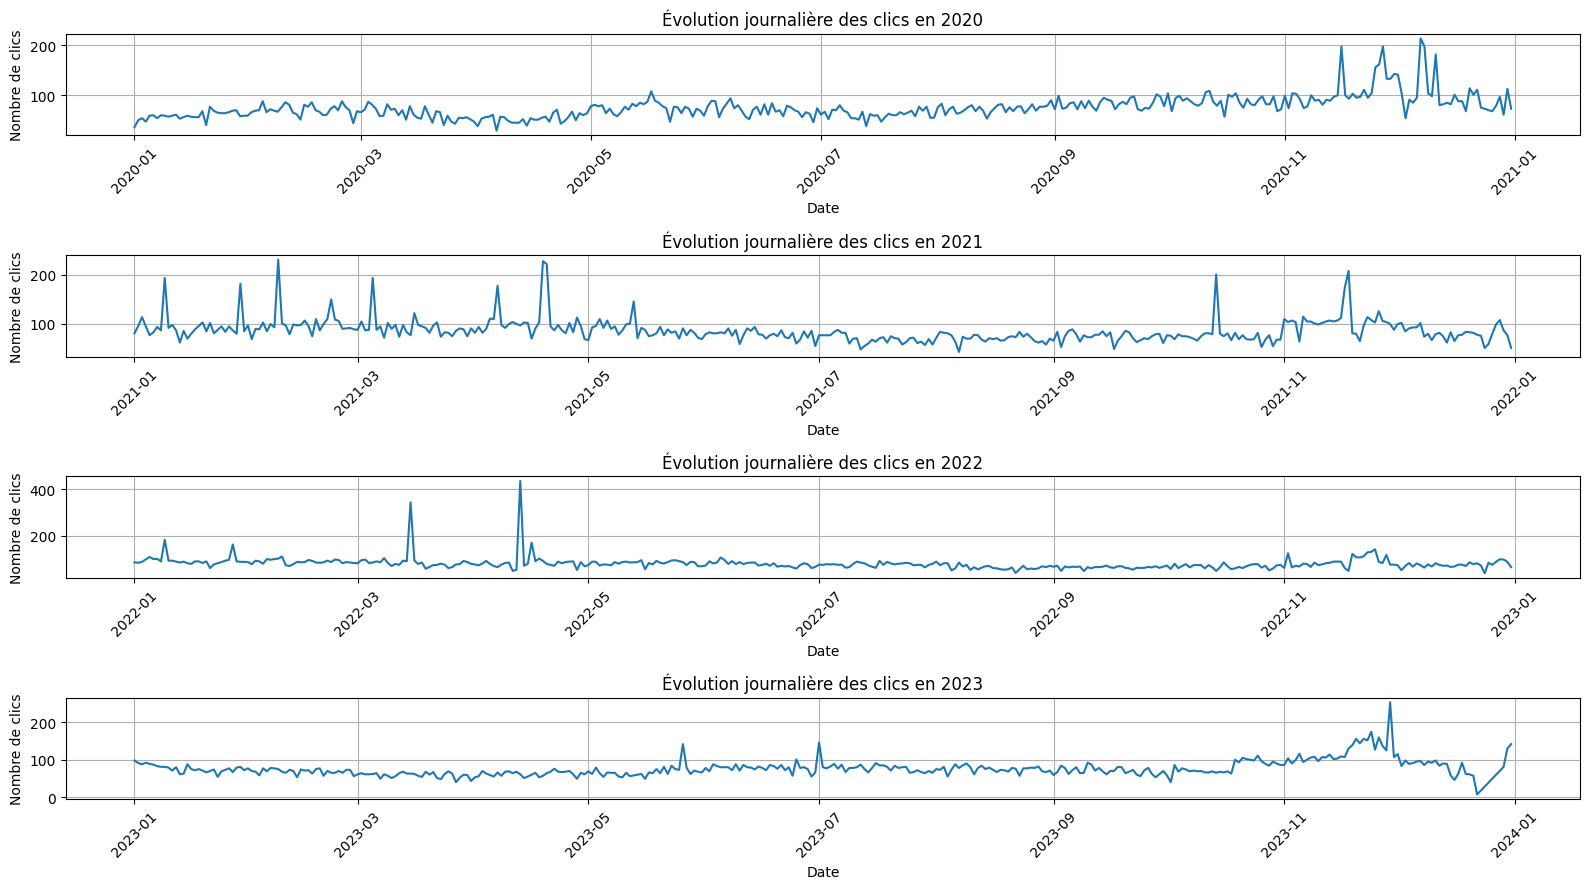

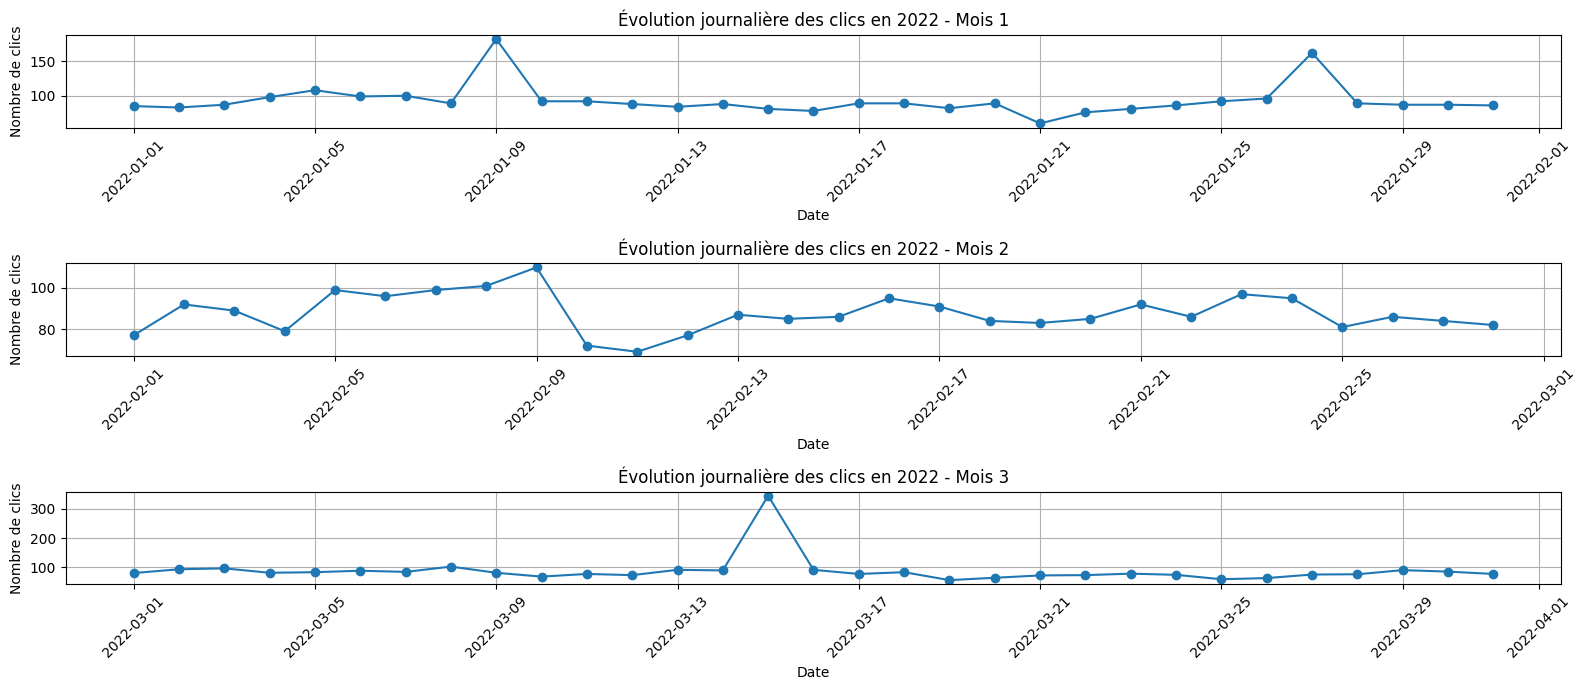

In [56]:
liste_id = df_train['ID'].unique()
i = 0  # Ici on considère un seul client juste pour illustrer. Les résultats dont les mêmes pour les autres clients
df_train_id = df_train[df_train['ID']==liste_id[i]]

## Pour les années 2020, 2021, 2022 et 2023
annees = [2020, 2021, 2022, 2023]
plt.figure(figsize=(16, 9))  # 3 graphiques verticalement

for i, annee in enumerate(annees, 1):
    df_year = df_train_id[df_train_id['date'].dt.year == annee]
    daily_clicks = df_year.groupby('date')['clicks'].sum()
    
    plt.subplot(len(annees), 1, i)
    plt.plot(daily_clicks.index, daily_clicks.values)
    plt.title(f"Évolution journalière des clics en {annee}")
    plt.xlabel("Date")
    plt.ylabel("Nombre de clics")
    plt.grid(True)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## Pour les mois de Janvier, Février et Mars de l'annéé 2022
annee_zoom = 2022
mois_zoom = [1, 2, 3]  # Janvier, février, mars
df_zoom = df_train_id[(df_train_id['date'].dt.year == annee_zoom) & (df_train_id['date'].dt.month.isin(mois_zoom))]
plt.figure(figsize=(16, 7))

for i, mois in enumerate(mois_zoom, 1):
    df_month = df_zoom[df_zoom['date'].dt.month == mois]
    daily_clicks = df_month.groupby('date')['clicks'].sum()
    
    plt.subplot(len(mois_zoom), 1, i)
    plt.plot(daily_clicks.index, daily_clicks.values, marker='o')
    plt.title(f"Évolution journalière des clics en {annee_zoom} - Mois {mois}")
    plt.xlabel("Date")
    plt.ylabel("Nombre de clics")
    plt.grid(True)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Bien qu’aucune saisonnalité marquée ne soit directement perceptible à l’œil nu dans les visualisations globales, cela n’exclut pas 
 
l’existence de motifs saisonniers plus fins. La présence d’une tendance forte, de pics extrêmes et l’agrégation des données peuvent
 
masquer des effets saisonniers de faible amplitude mais réguliers. L’introduction de variables temporelles explicites (jour de la 

semaine, mois, semaine de l’année) permet aux modèles d’exploiter ces régularités, même lorsqu’elles ne sont pas immédiatement 

visibles dans les graphiques.

### 3. Features Engineering

Notre démarche de feature engineering consiste à transformer des données publicitaires brutes en une série temporelle riche, en combinant mémoire historique (lags), contexte calendaire et statistiques globales, afin de permettre une prédiction fiable et interprétable des clics futurs.

1. **Structuration temporelle des données (fonction template_train_set)**
On reconstruis une série temporelle continue (sans jours manquants). Cela consiste à crée les jours qui n'existent pas (pour chaque client) afin d'éviter toute fuite temporelle. Par ailleurs, sans cette étape les lags et tendances seraient incohérents.

2. **Création de features calendaires : donner le sens du temps au modèle  (fonction features_date)**
On rajoute des features de type date pour permettre au modèle de capter une possible saisonnalité, les cycles et les contraintes business qui se répètent dans le temps, et qui ne sont pas visibles dans les données brutes. On rajoute  à cela une variable pour capter le changement le régime (*post_change*) et une autre pour tenir compte des jours fériés en Afrique du Sud.

3. **Statistiques globales par période**
Pour capter des patterns hebdomadaires (features_stat_semaine) ou mensuel (features_stat_mois). Cela permettra de stabiliser les prédictions, comprendre le contexte du mois/semaine.

4. **Features retardées et Différences entre lags (fonction features_lags)**
Les lags permettent au modèle de se souvenir du passé. On commence par le lag à j-7 car on prédit à une semaine (les lag 7 à 14 sont rajoutés pour les variables : 'clicks', 'impressions', 'cost'). les différences entre lags proches permettent de capter, une accélération, un ralentissement ou des ruptures de tendance. Elles sont souvent utiles en période de transition (Notre graphe plus haut nous a montré un changement de régime).

In [12]:
df_train.sort_values(by = ['ID', 'date'], inplace=True)

In [13]:
def semaine_du_mois(valeur_date):
    """Calcul à quelle semaine du mois appartient la date."""
    result = valeur_date.day + valeur_date.replace(day=1).weekday()
    return int(np.ceil(result / 7))

liste_jours_feries = [
        (16, 12), # Jour de la réconciliation
        (25, 12), # fête de Noël
        (1, 1),   # Jour du nouvel an
        (27, 4),  # Jour de la liberté
        (1, 5),   # fête du travail
        (9, 8),   # Jour National de la femme
        (24, 9),  # Journée du patrimoine
        (26, 12),  # Jour de la Bonne Volonté
        (21, 3),  # Jour des droits de l'homme
        (16, 6),  # fête de la jeunesse
    ]

def template_train_set(df, id):
    """Construit le dataframe de telle manière à garantir une ligne par jour (aucun trou temporel), même si le client
    n'avait pas de données certains jours."""
    dates = pd.date_range(start=df['date'].min(), end=df['date'].max())
    df_avec_toutes_les_dates = pd.DataFrame({'date' : dates, 'ID' : id})
    result = pd.merge(df_avec_toutes_les_dates, df, on=['date', 'ID'], how='left')
    return result

def features_date(df):
    """Fonction qui calcule les nouvelles features à partir de la date (pour capter si possible la saisonnalité si elle existe)."""
    ## features temporelles
    df['jour'] = df['date'].dt.day # extraction du jour du mois correspondant à la date du clic
    df['annee'] = df['date'].dt.year # annee conrrespondante à la date du clic
    df['mois'] = df['date'].dt.month # mois correspondant à la date du clic
    df['semaine'] = df['date'].dt.isocalendar().week # numero de la semaine de l'année (selon la norme ISO)
    df['jour_de_annee'] = df['date'].dt.dayofyear # extraction du rang du jour dans l'annee
    df['jour_de_semaine'] = df['date'].dt.dayofweek # extraction du rang du jour de la semaine
    df['trismestre_annee'] = df['date'].dt.quarter # trimestre de l'annee correspondant à la date
    df['weekend'] = df['date'].dt.dayofweek >= 5 # variable booleenne weekend (1 si oui 0 sinon)
    df['premier_du_mois'] = df['date'].dt.is_month_start.astype(int) # premier jour du mois (booleen)
    df['dernier_du_mois'] = df['date'].dt.is_month_end.astype(int)  # dernier jour du mois (booleen)
    df['semaine_du_mois'] = df['date'].apply(semaine_du_mois)  # extraction de la semaine du mois
    df['jours_ferie'] = df['date'].apply(lambda d: any(abs((d - pd.Timestamp(year=d.year, month=m, day=j)).days) <= 1
                  for j, m in liste_jours_feries)) # 1 si le jour est férié ou à la veille et le lendemain d'un jour férié
    df['post_change'] = df['date'] >= '2022-06-01' # Pour capturer un changement le régime (entre le type de publicité)
    return df

def features_cat(df):
    ad_type_dummies = pd.get_dummies(df['ad_type'], dtype=bool)
    currency_dummies = pd.get_dummies(df['currency'], dtype=bool)
    df = pd.concat([df, ad_type_dummies], axis=1)
    df = pd.concat([df, currency_dummies], axis=1)
    df.drop(['ad_type', 'currency'], axis=1, inplace=True)
    return df

def features_lags(df, cols, lags, lags_diff):
    """Calcul des lags et des différences entre lags."""
    df.sort_values(by = ['date'], inplace=True)
    # lags
    for col in cols:
            for shift in lags:
                df[f"lag_{col}_{shift}"] = df[col].shift(shift)
    
    # différences entre lags
    for col in cols:
            for shift in lags_diff:
                df[f"diff_{col}_lag_{shift}"] = df[f"lag_{col}_{lags_diff[0]}"] - df[f"lag_{col}_{shift}"]
    return df

def features_stat_semaine(df):
     """Calcul des features statistiques par semaine : mean, std, min, max."""
     # stat par semaine
     df_semaine = df.groupby('semaine').agg({
          'clicks':['mean', 'std', 'min', 'max'],
          'impressions': ['mean', 'std', 'min', 'max'],
          'cost': ['mean', 'std', 'min', 'max']
     }).reset_index()
     df_semaine.columns = ['semaine'] + [f"semaine_{col}_{stat}" for col, stat in df_semaine.columns[1:]]
     return df_semaine

def features_stat_mois(df):
     """Calcul des features statistiques par mois : mean, std, min, max."""
     # stat par mois
     df_mois = df.groupby('mois').agg({
          'clicks':['mean', 'std', 'min', 'max'],
          'impressions': ['mean', 'std', 'min', 'max'],
          'cost': ['mean', 'std', 'min', 'max']
     }).reset_index()
     df_mois.columns = ['mois'] + [f"mois_{col}_{stat}" for col, stat in df_mois.columns[1:]]
     return df_mois

In [14]:
df_train_2 = features_cat(df_train)

In [15]:
def construction_train_set(df, id):
    """Processus de construction du Train Set."""
    train_id_set = df[df['ID'] == id] # on fait les preprocessing pour chaque ID (chaque client)
    train_template = template_train_set(train_id_set, id) # on applique la fonction template_train_set
    train_feature_date = features_date(train_template) # on applique la fonction features_dates

    # On aggrège le dataframe car plusieurs observation pour une même date
    train_feature_date_agg = train_feature_date.groupby('date').agg({
        'impressions': 'sum',
        'clicks': 'sum',
        'cost' : 'sum',
        'EXPANDED_DYNAMIC_SEARCH_AD': 'max',
        'EXPANDED_TEXT_AD': 'max',
        'RESPONSIVE_SEARCH_AD': 'max',
        'ZAR': 'max',
        'USD': 'max',
        'ID': 'first',
        'jour': 'first',
        'semaine_du_mois': 'first',
        'trismestre_annee': 'first',
        'mois': 'first',
        'weekend': 'first',
        'jour_de_annee': 'first',
        'premier_du_mois': 'first',
        'annee': 'first',
        'semaine': 'first',
        'dernier_du_mois': 'first',
        'jours_ferie' : 'first',
        'jour_de_semaine':'first',
        'post_change':'first'
    }).reset_index()

    # création des colonnes stats
    stat_semaine = features_stat_semaine(train_feature_date)
    stat_mois = features_stat_mois(train_feature_date)
    train_feature_date_agg = pd.merge(train_feature_date_agg, stat_mois, on='mois', how='left')
    train_feature_date_agg = pd.merge(train_feature_date_agg, stat_semaine, on='semaine', how='left')

    # création des colonnes lags
    lag_cols = ['clicks', 'impressions', 'cost'] # colonnes à lagger
    train = features_lags(train_feature_date_agg, lag_cols, range(7, 15), range(8, 15))
    train.drop(['impressions', 'cost'], axis=1, inplace=True)
    return train

In [ ]:
## On applique la fonction de construction du Train pour chaque ID (client)
train_set_par_id = []
for id in [df_train_2['ID'].unique()][0]:
    train_set = construction_train_set(df_train_2, id)
    train_set_par_id.append(train_set)

In [ ]:
### DATAFRAME D'ENTRAINEMENT : on concatène les train des clients pour former le dataframe final
train = pd.concat(train_set_par_id)
encode = LabelEncoder()
train['ID'] = encode.fit_transform(train['ID'])
train = train.sort_values(by=['date', 'ID']).reset_index(drop=True)

bool_cols = ["EXPANDED_DYNAMIC_SEARCH_AD", "EXPANDED_TEXT_AD",
             "RESPONSIVE_SEARCH_AD", "ZAR", "USD"]

# Conversion en bool
for col in bool_cols:
    train[col] = train[col].astype(bool)

### 4. MODELISATION et EVALUATION : Sélection des modèles et métriques 

Le problème étudié consiste à prédire le nombre de clics futurs (variable continue) à l’horizon J+7

Il s’agit donc :
- d’un problème de **régression supervisée**,
- sur des **données tabulaires hétérogènes** (numériques + catégorielles),
- qui ont des **relations non linéaires**,
- avec une **structure temporelle** qui impose une validation qui respecte l’ordre chronologique

Les modèles selectionnés doivent :
- capturer des interactions complexes,
- être robustes aux distributions asymétriques,
- bien fonctionner sur un grand jeux de données 

---

### Justification du choix des modèles

Trois modèles ont été retenus : **Random Forest**, **XGBoost** et **LightGBM**.

####  Random Forest
Le Random Forest est un modèle d’ensemble basé sur des arbres de décision indépendants.

Ses avantages dans notre contexte :
- robuste au bruit et aux valeurs extreme,
- capable de modéliser des relations non linéaires,
- peu sensible à l’échelle des variables,
- fournit une première référence solide (baseline non linéaire, c'est le modele benchmark).
- modele simple et interpretable 


---

#### XGBoost
XGBoost est un algorithme de gradient boosting performant pour les données tabulaires.

Avantages dans notre cas :
- bonne capacité à capturer des interactions complexes entre variables (coût × impressions × type d’annonce),
- gestion efficace des grandes dimensions ,
- mécanismes internes de régularisation limitant l’overfitting (le modele corrige les erreurs pas à pas),

---

####  LightGBM
LightGBM est une version optimisée du gradient boosting, particulièrement adaptée aux grands jeux de données.

Avantages spécifiques pour ce projet :
- entraînement rapide même avec un grand nombre d’observations, 
- bonne performance sur données hétérogènes,
- réduction du risque d’overfitting grâce à la croissance par feuilles (`num_leaves`, `min_child_samples`).


---

###  Pourquoi ne pas utiliser d’autres modèles ?

Certains modèles n’ont pas été retenus pour les raisons suivantes :

- **Régression linéaire** : trop restrictive pour capturer les relations non linéaires entre impressions, coût et clics.
- **Réseaux de neurones (DL)** : nécessitent davantage de données, sont plus difficiles à interpréter et à stabiliser sur des données tabulaires classiques.
- **Modèles ARIMA / séries temporelles univariées** : ne prennent pas en compte les nombreuses variables explicatives (features marketing).
- **k-NN ou SVR** : peu adaptés à des jeux de données volumineux et à forte dimension.

Les modèles d’arbres boostés offrent un meilleur compromis entre performance, robustesse et interprétabilité.

---

###  Choix de la métrique : RMSE

La métrique principale utilisée est la **Root Mean Squared Error (RMSE)** pertinente pour ce problème car :
- elle est exprimée dans la même unité que la variable cible (nombre de clics),
- elle pénalise fortement les grandes erreurs de prédiction,
- adaptée quand on souhaite éviter des sous-estimations importantes,
- elle est standard en régression pour comparer différents modèles.

Dans un contexte marketing, une erreur importante sur certaines campagnes peut entraîner une mauvaise allocation du budget publicitaire. Il est donc essentiel de pénaliser fortement ces erreurs, ce que permet la RMSE.


---

### Validation croisée temporelle

La validation croisée utilisée repose sur un découpage basé sur les dates :
- les données d’entraînement sont toujours antérieures aux données de test,
- ce choix évite le **data leakage**,
- il permet d’évaluer la capacité du modèle à prédire des données futures.

Pour chaque fold :
- l’ensemble de test correspond à une période de 7 jours consécutifs,
- l’ensemble d’entraînement est composé des observations antérieures à cette période,
- on repète le découpage sur 5 fenêtres temporelles successives (5 fold).


Chaque modèle est évalué sur plusieurs fenêtres temporelles (folds), la RMSE est calculée pour chaque fold, puis une moyenne est obtenue afin d’évaluer la performance globale du modèle.


In [18]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
import xgboost as xgb
from xgboost import XGBRegressor
from math import sqrt

In [19]:
X = [c for c in train.columns if c not in ["date", "clicks"]]
train = train.dropna(subset=["clicks"])

# tscv = TimeSeriesSplit(
#     n_splits=5,
#     test_size=14,
#     gap=7,
#     max_train_size=20000
# )

In [20]:
def get_date_based_splits(df, n_splits=5, test_days=7):
    """
    Renvoie les indices de train et test basés sur les dates.
    df doit être trié par date puis ID.
    """
    unique_dates = np.sort(df['date'].unique())
    splits = []

    # On fait n_splits sur la fin des données
    for i in range(n_splits):
        test_end = unique_dates[-(i * test_days + 1)]
        test_start = unique_dates[-((i + 1) * test_days)]
        test_dates = unique_dates[(unique_dates >= test_start) & (unique_dates <= test_end)]
        
        test_idx = df[df['date'].isin(test_dates)].index
        train_idx = df[df['date'] < test_start].index

        splits.append((train_idx, test_idx))
    
    # Inverser pour que les splits soient chronologiques
    return splits[::-1]


In [22]:
splits = get_date_based_splits(train, n_splits=5, test_days=7)
splits

[(RangeIndex(start=0, stop=77581, step=1),
  RangeIndex(start=77581, stop=78334, step=1)),
 (RangeIndex(start=0, stop=78334, step=1),
  RangeIndex(start=78334, stop=79040, step=1)),
 (RangeIndex(start=0, stop=79040, step=1),
  RangeIndex(start=79040, stop=79728, step=1)),
 (RangeIndex(start=0, stop=79728, step=1),
  RangeIndex(start=79728, stop=80391, step=1)),
 (RangeIndex(start=0, stop=80391, step=1),
  RangeIndex(start=80391, stop=81008, step=1))]

In [48]:
scores = []
for fold, (train_idx, test_idx) in enumerate(splits):
    X_train, X_test = train.loc[train_idx, X], train.loc[test_idx, X]
    y_train, y_test = train.loc[train_idx, "clicks"], train.loc[test_idx, "clicks"]

    model_lgb = lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=64,
        random_state=42,
        n_jobs=-1
    )

    model_lgb.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric="rmse",
        categorical_feature=["ID"] # ID en catégorie
    )

    preds = model_lgb.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    scores.append(rmse)

    print(f"Fold {fold+1} rmse = {rmse:.2f}")

print("RSME moyen:", np.mean(scores))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012678 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16462
[LightGBM] [Info] Number of data points in the train set: 77581, number of used features: 88
[LightGBM] [Info] Start training from score 28.370658
Fold 1 rmse = 75.47
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014424 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16466
[LightGBM] [Info] Number of data points in the train set: 78334, number of used features: 88
[LightGBM] [Info] Start training from score 28.514298
Fold 2 rmse = 26.70
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012311 seconds.
You can set `force_row_wise=true` to rem

Text(0.5, 1.0, 'Lightgbm features importance (top 50):')

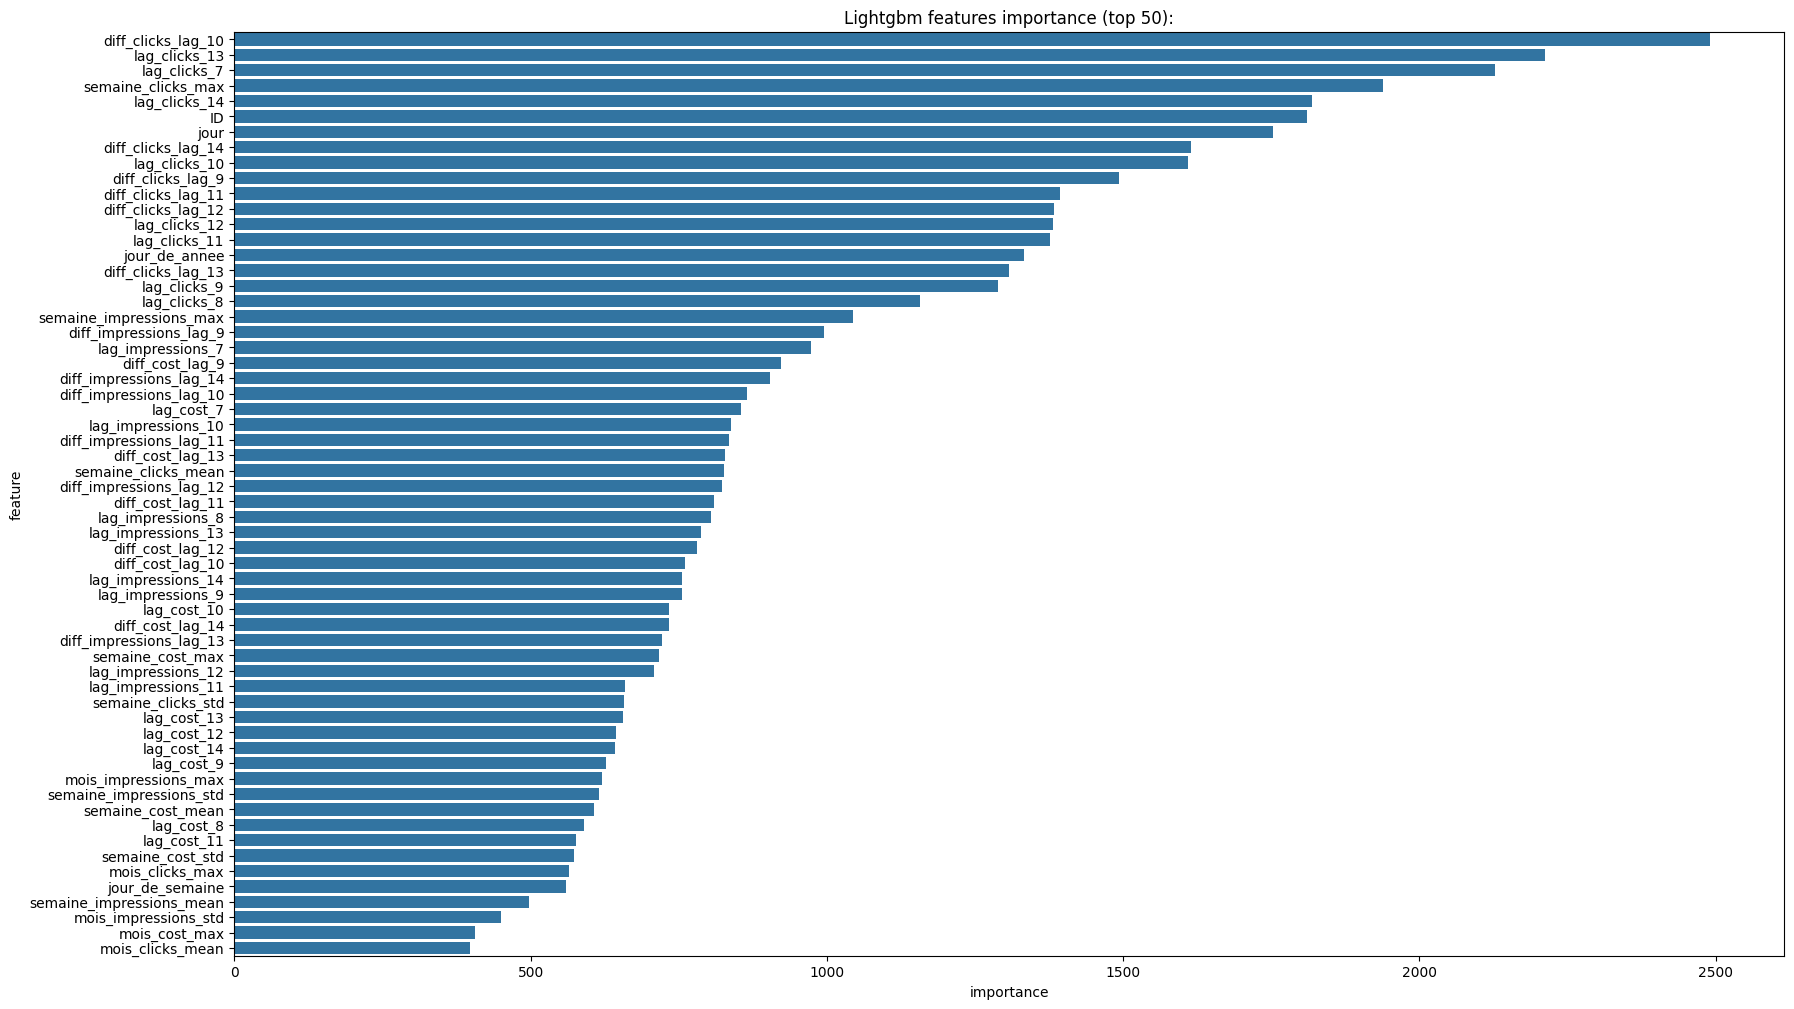

In [49]:
feature_importance = pd.DataFrame(model_lgb.feature_importances_, columns=['importance'])
feature_importance['feature'] = X

plt.figure(figsize=(20, 12))
sns.barplot(x="importance", y="feature", data=feature_importance.sort_values(by = ['importance'], ascending = False).head(60))
plt.title('Lightgbm features importance (top 50):')

In [50]:
## Random Forest
scores = []
for fold, (train_idx, test_idx) in enumerate(splits):
    X_train, X_test = train.loc[train_idx, X], train.loc[test_idx, X]
    y_train, y_test = train.loc[train_idx, "clicks"], train.loc[test_idx, "clicks"]

    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )

    rf.fit( X_train, y_train)

    preds = rf.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    scores.append(rmse)

    print(f"Fold {fold+1} rmse = {rmse:.2f}")

print("RSME moyen:", np.mean(scores))


Fold 1 rmse = 68.84
Fold 2 rmse = 26.42
Fold 3 rmse = 27.14
Fold 4 rmse = 64.01
Fold 5 rmse = 26.59
RSME moyen: 42.601065348974025


Text(0.5, 1.0, 'Lightgbm features importance (top 50):')

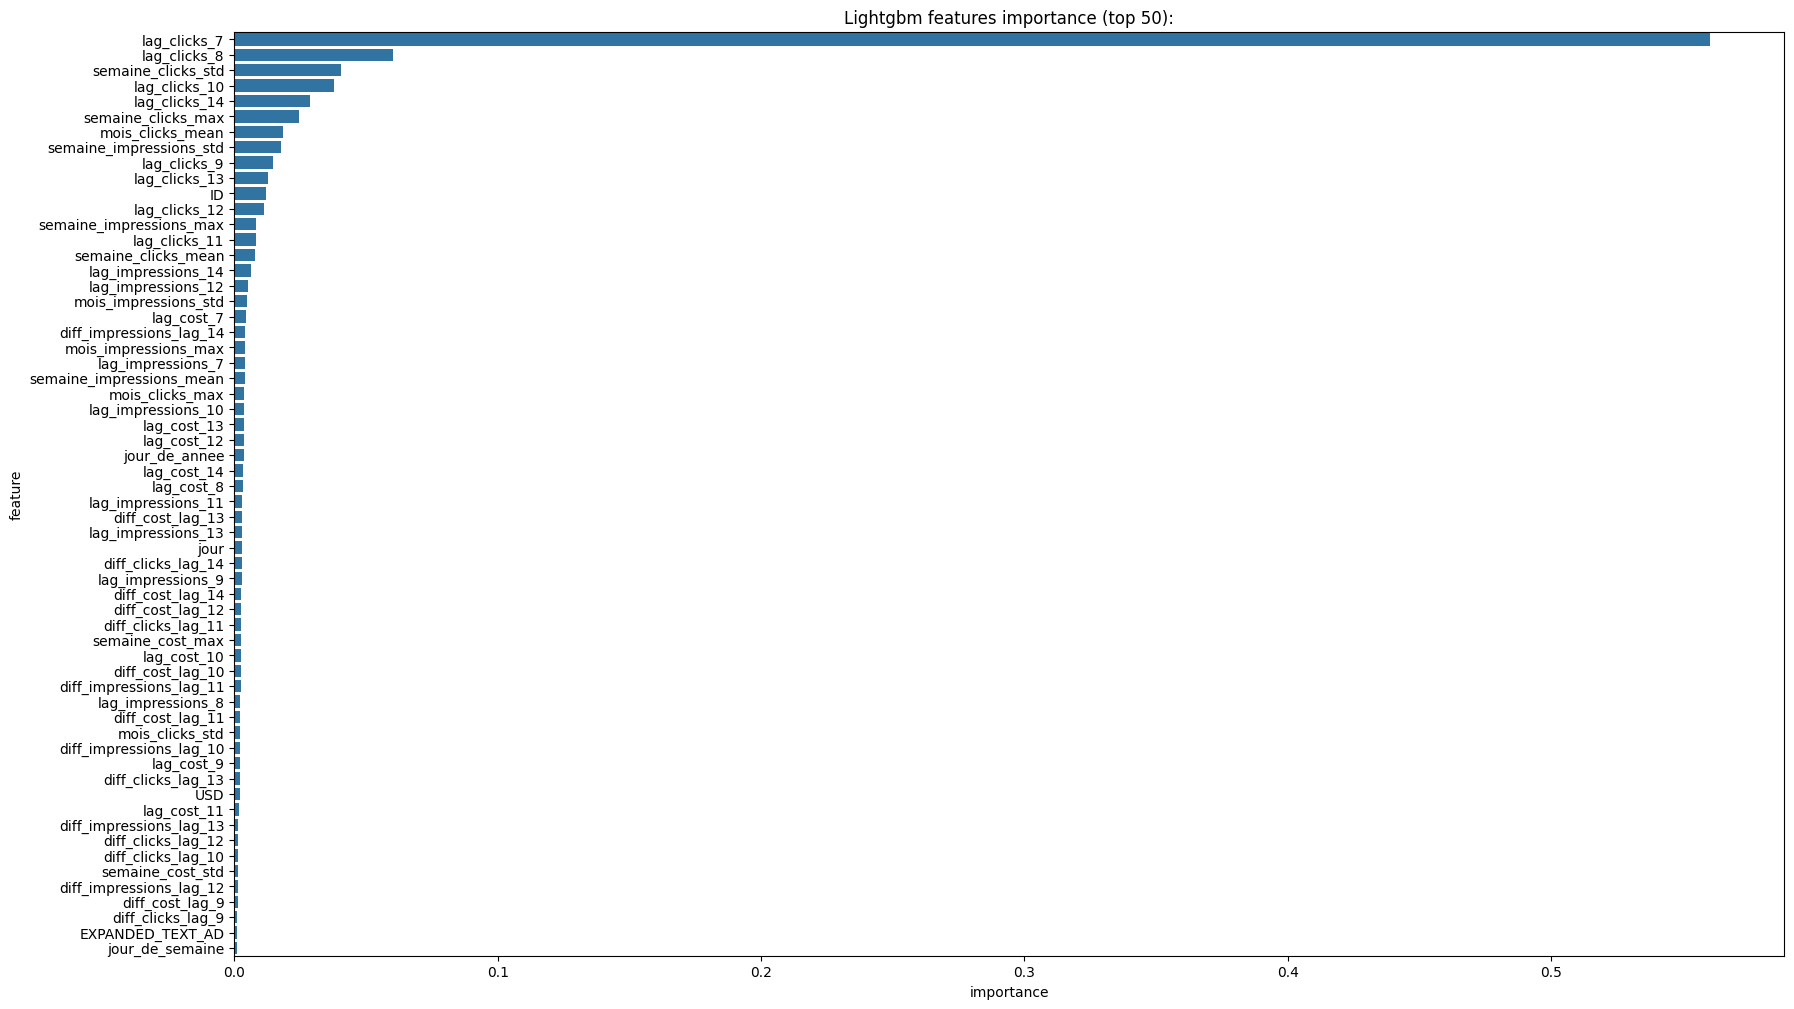

In [51]:
feature_importance = pd.DataFrame(rf.feature_importances_, columns=['importance'])
feature_importance['feature'] = X

plt.figure(figsize=(20, 12))
sns.barplot(x="importance", y="feature", data=feature_importance.sort_values(by = ['importance'], ascending = False).head(60))
plt.title('Lightgbm features importance (top 50):')

In [52]:
## Xgboost
scores = []
for fold, (train_idx, test_idx) in enumerate(splits):
    X_train, X_test = train.loc[train_idx, X], train.loc[test_idx, X]
    y_train, y_test = train.loc[train_idx, "clicks"], train.loc[test_idx, "clicks"]

    model_xgb = xgb.XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    model_xgb.fit( X_train, y_train)

    preds = model_xgb.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    scores.append(rmse)

    print(f"Fold {fold+1} rmse = {rmse:.2f}")

print("RSME moyen:", np.mean(scores))

Fold 1 rmse = 59.73
Fold 2 rmse = 25.84
Fold 3 rmse = 38.55
Fold 4 rmse = 56.82
Fold 5 rmse = 23.95
RSME moyen: 40.97782305629902


Text(0.5, 1.0, 'Lightgbm features importance (top 50):')

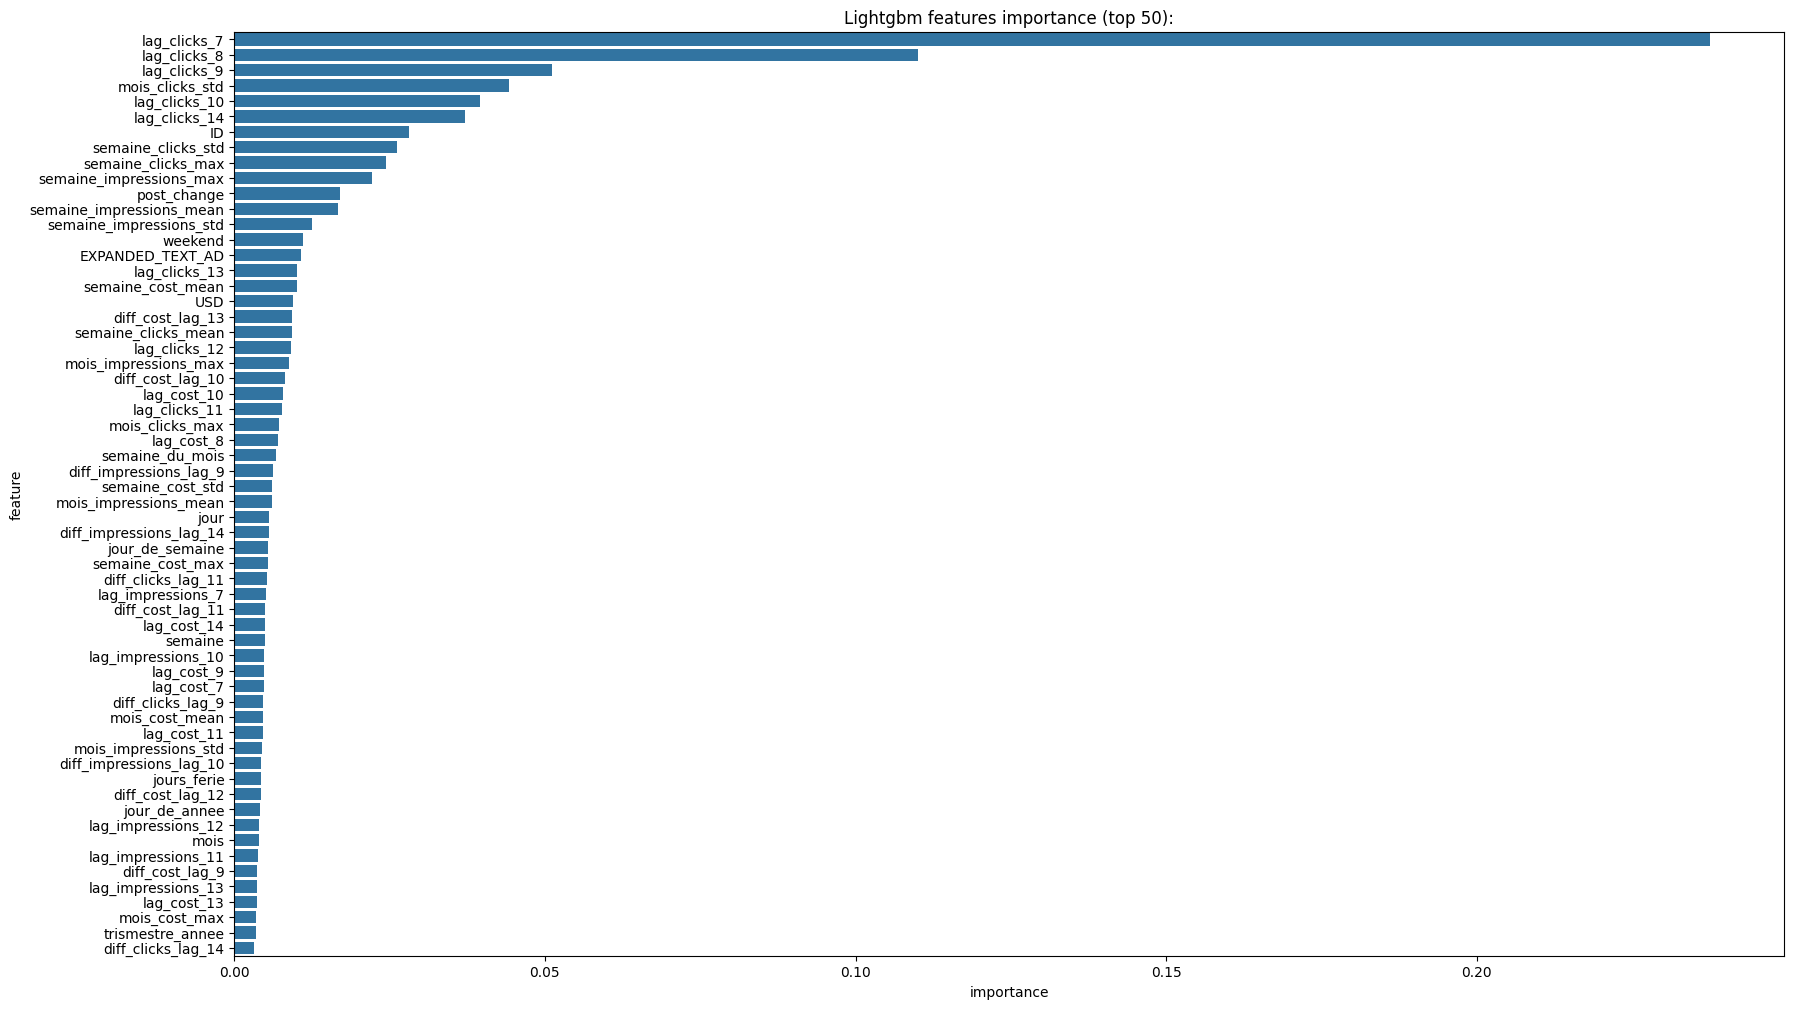

In [53]:
feature_importance = pd.DataFrame(model_xgb.feature_importances_, columns=['importance'])
feature_importance['feature'] = X

plt.figure(figsize=(20, 12))
sns.barplot(x="importance", y="feature", data=feature_importance.sort_values(by = ['importance'], ascending = False).head(60))
plt.title('Lightgbm features importance (top 50):')

In [54]:
# num_vars = [ 'impressions', 'cost', 'conversions', 'impression_share', 'headline1_len', 'headline2_len', 'ad_description_len']
# cat_vars = ['ad_type', 'currency']
# results_num = []
# results_cat = []

# for var in num_vars:
#     df_tmp = df_train[[var, 'clicks']].dropna()
    
#     pearson_corr, pearson_p = pearsonr(df_tmp[var], df_tmp['clicks'])
#     spearman_corr, spearman_p = spearmanr(df_tmp[var], df_tmp['clicks'])
    
#     results_num.append({
#         'variable': var,
#         'pearson_corr': pearson_corr,
#         'pearson_pvalue': pearson_p,
#         'spearman_corr': spearman_corr,
#         'spearman_pvalue': spearman_p
#     })

# results_num_df = pd.DataFrame(results_num)
# display(results_num_df.sort_values('pearson_pvalue'))



# for var in cat_vars:
#     groups = [
#         df_train[df_train[var] == cat]['clicks'].dropna()
#         for cat in df_train[var].unique()
#     ]
    
#     stat, p = kruskal(*groups)
    
#     results_cat.append({
#         'variable': var,
#         'test': 'Kruskal-Wallis',
#         'p_value': p
#     })

# results_cat_df = pd.DataFrame(results_cat)
# results_cat_df

# Optimisation des hyperparamètres 

Dans cette partie, on cherche à optimiser les performances des modèles en ajustant leurs hyperparamètres.  
Pour cela, on utilise une méthode de **Grid Search** combinée à une validation croisée temporelle.

L’optimisation est réalisée séparément pour chaque horizon de prévision :
- 7 jours,
- 14 jours,
- 21 jours.

Cela permet d’obtenir des modèles adaptés à chaque horizon.

---

### Principe du Grid Search

Le Grid Search consiste à tester toutes les combinaisons possibles d’un ensemble d’hyperparamètres définis à l’avance.  
Pour chaque combinaison, le modèle est entraîné et évalué sur plusieurs périodes de validation grâce à la validation croisée temporelle.


La combinaison d’hyperparamètres qui minimise le RMSE moyen est sélectionnée comme la meilleure configuration.


### Nombre de modèles évalués

Pour chaque horizon, trois modèles sont étudiés : LightGBM, Random Forest, XGBoost

Chaque modèle est associé à une grille d’hyperparamètres composée de plusieurs valeurs possibles.  
Pour un horizon donné, plusieurs dizaines de configurations différentes sont testées automatiquement.

En prenant en compte les trois horizons (7, 14 et 21 jours) et les trois modèles, le nombre total de modèles entraînés est élevé.  
Chaque combinaison d’hyperparamètres est évaluée sur plusieurs folds de validation croisée, ce qui multiplie encore le nombre d’entraînements.

Ainsi, au total, plusieurs centaines de modèles sont entraînés et comparés


### Impact sur le temps de calcul

Cette stratégie d’optimisation est performante mais coûteuse en temps de calcul.  
En effet, chaque modèle doit être réentraîné plusieurs fois pour chaque combinaison de paramètres et pour chaque horizon.

Le temps d’exécution est donc long.
Cependant, ce choix est justifié par la nécessité d’obtenir une comparaison fiable et rigoureuse des modèles.

---

### Optimisation spécifique à chaque horizon

La recherche d’hyperparamètres est réalisée indépendamment pour chaque horizon :
- un ensemble de paramètres est optimisé pour les prévisions à 7 jours,
- un autre pour 14 jours,
- et un autre pour 21 jours.


### Sélection finale des modèles

À l’issue du Grid Search, on conserve pour chaque horizon :
- le modèle ayant obtenu le RMSE moyen le plus faible,
- ainsi que les hyperparamètres correspondants.

Les résultats sont ensuite regroupés dans un tableau final qui présente, pour chaque horizon, le meilleur modèle et ses paramètres optimaux.




In [ ]:
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.ensemble import RandomForestRegressor

import lightgbm as lgb
import xgboost as xgb

RANDOM_STATE = 42

def make_horizon_dataset(df, horizon, target_col="clicks", group_col="ID"):
    dfh = df.sort_values(["date", group_col]).copy()
    dfh["y"] = dfh.groupby(group_col)[target_col].shift(-horizon)
    dfh = dfh.dropna(subset=["y"]).copy()
    return dfh

def splits_to_predefinedsplit(df, splits):
    """
    Robuste: marche si test_idx = positions OU labels.
    """
    n = len(df)
    test_fold = np.full(n, -1, dtype=int)
    pos_map = {idx: pos for pos, idx in enumerate(df.index)}

    for k, (_, test_idx) in enumerate(splits):
        arr = np.asarray(list(test_idx))
        if np.issubdtype(arr.dtype, np.integer) and arr.size > 0 and arr.min() >= 0 and arr.max() < n:
            test_pos = arr.astype(int)
        else:
            test_pos = np.array([pos_map[i] for i in test_idx if i in pos_map], dtype=int)
        test_fold[test_pos] = k

    return PredefinedSplit(test_fold)

def rmse_from_neg_score(best_score):
    # scoring = neg_root_mean_squared_error
    return -float(best_score)

# Horizons demandés
HORIZONS = [0, 7, 14]  #[7, 14, 21]

all_results = []

for h in HORIZONS:
    print(f"\n================= Horizon {h} jours =================")

    # 1) dataset horizon + reset index (important)
    df_h = make_horizon_dataset(train, horizon=h, target_col="clicks", group_col="ID").reset_index(drop=True)

    # 2) splits date-based (ta fonction)
    splits_h = get_date_based_splits(df_h, n_splits=5, test_days=h)
    cv = splits_to_predefinedsplit(df_h, splits_h)

    # 3) features / cible
    feature_cols = [c for c in df_h.columns if c not in ["date", "clicks", "y"]]
    X = df_h[feature_cols].copy()
    y = df_h["y"].copy()

    # ---------- LightGBM ----------
    fit_params_lgb = {}
    if "ID" in X.columns:
        try:
            X["ID"] = X["ID"].astype("category")
            fit_params_lgb = {"categorical_feature": ["ID"]}
        except Exception:
            fit_params_lgb = {}

    lgb_model = lgb.LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    lgb_grid = {
        "n_estimators": [400, 800],
        "learning_rate": [0.05, 0.10],
        "num_leaves": [31, 63],
    }

    gs_lgb = GridSearchCV(lgb_model, lgb_grid, scoring="neg_root_mean_squared_error", cv=cv, n_jobs=-1, verbose=0)
    gs_lgb.fit(X, y, **fit_params_lgb)

    all_results.append({
        "horizon_days": h,
        "model": "LightGBM",
        "rmse_mean": rmse_from_neg_score(gs_lgb.best_score_),
        "best_params": gs_lgb.best_params_
    })
    print(f"LightGBM     | RMSE = {-gs_lgb.best_score_:.4f} | {gs_lgb.best_params_}")

    # ---------- RandomForest ----------
    rf_model = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
    rf_grid = {
        "n_estimators": [300, 600],
        "max_depth": [None, 12],
        "min_samples_leaf": [1, 3],
        "max_features": ["sqrt"],
    }

    gs_rf = GridSearchCV(rf_model, rf_grid, scoring="neg_root_mean_squared_error", cv=cv, n_jobs=-1, verbose=0)
    gs_rf.fit(X, y)

    all_results.append({
        "horizon_days": h,
        "model": "RandomForest",
        "rmse_mean": rmse_from_neg_score(gs_rf.best_score_),
        "best_params": gs_rf.best_params_
    })
    print(f"RandomForest | RMSE = {-gs_rf.best_score_:.4f} | {gs_rf.best_params_}")

    # ---------- XGBoost ----------
    xgb_model = xgb.XGBRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        objective="reg:squarederror",
        tree_method="hist",
        verbosity=0
    )
    xgb_grid = {
        "n_estimators": [400, 900],
        "learning_rate": [0.05, 0.10],
        "max_depth": [4, 7],
    }

    gs_xgb = GridSearchCV(xgb_model, xgb_grid, scoring="neg_root_mean_squared_error", cv=cv, n_jobs=-1, verbose=0)
    gs_xgb.fit(X, y)

    all_results.append({
        "horizon_days": h,
        "model": "XGBoost",
        "rmse_mean": rmse_from_neg_score(gs_xgb.best_score_),
        "best_params": gs_xgb.best_params_
    })
    print(f"XGBoost      | RMSE = {-gs_xgb.best_score_:.4f} | {gs_xgb.best_params_}")

# ===== Tableaux finaux =====
results_df = pd.DataFrame(all_results).sort_values(["horizon_days", "rmse_mean"]).reset_index(drop=True)
print("\n================= Résultats (tous modèles, triés) =================")
display(results_df)

best_by_h = results_df.loc[results_df.groupby("horizon_days")["rmse_mean"].idxmin()].sort_values("horizon_days").reset_index(drop=True)
print("\n================= Meilleur modèle par horizon =================")
display(best_by_h)



================= Horizon 7 jours =================
LightGBM     | RMSE = 53.1966 | {'learning_rate': 0.05, 'n_estimators': 400, 'num_leaves': 63}


/Users/benallal/Documents/ÉTUDES/M2/deeplearning2/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RandomForest | RMSE = 48.0750 | {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 300}
XGBoost      | RMSE = 58.2537 | {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 400}

================= Horizon 14 jours =================
LightGBM     | RMSE = 53.3895 | {'learning_rate': 0.05, 'n_estimators': 400, 'num_leaves': 63}


/Users/benallal/Documents/ÉTUDES/M2/deeplearning2/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RandomForest | RMSE = 48.8158 | {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 300}
XGBoost      | RMSE = 58.5106 | {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 400}

================= Horizon 21 jours =================
LightGBM     | RMSE = 55.8600 | {'learning_rate': 0.1, 'n_estimators': 400, 'num_leaves': 31}


/Users/benallal/Documents/ÉTUDES/M2/deeplearning2/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RandomForest | RMSE = 51.4457 | {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 600}
XGBoost      | RMSE = 58.4794 | {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 900}

================= Résultats (tous modèles, triés) =================


,horizon_days,model,rmse_mean,best_params
0,7,RandomForest,48.074959,"{'max_depth': None, 'max_features': 'sqrt', 'm..."
1,7,LightGBM,53.196617,"{'learning_rate': 0.05, 'n_estimators': 400, '..."
2,7,XGBoost,58.253720,"{'learning_rate': 0.05, 'max_depth': 7, 'n_est..."
3,14,RandomForest,48.815839,"{'max_depth': None, 'max_features': 'sqrt', 'm..."
4,14,LightGBM,53.389482,"{'learning_rate': 0.05, 'n_estimators': 400, '..."
5,14,XGBoost,58.510602,"{'learning_rate': 0.1, 'max_depth': 7, 'n_esti..."
6,21,RandomForest,51.445654,"{'max_depth': None, 'max_features': 'sqrt', 'm..."
7,21,LightGBM,55.860041,"{'learning_rate': 0.1, 'n_estimators': 400, 'n..."
8,21,XGBoost,58.479382,"{'learning_rate': 0.1, 'max_depth': 7, 'n_esti..."



================= Meilleur modèle par horizon =================


,horizon_days,model,rmse_mean,best_params
0,7,RandomForest,48.074959,"{'max_depth': None, 'max_features': 'sqrt', 'm..."
1,14,RandomForest,48.815839,"{'max_depth': None, 'max_features': 'sqrt', 'm..."
2,21,RandomForest,51.445654,"{'max_depth': None, 'max_features': 'sqrt', 'm..."


# Discussion autour de la performance des modèles

## 1. Synthèse des résultats


- **RandomForest** est le modèle le plus performant pour tous les horizons.
- **LightGBM** arrive en seconde position avec une RMSE supérieure d’environ 8 à 10 %.
- **XGBoost** présente les performances les plus faibles, avec une RMSE supérieure d’environ 12 à 17 % selon l’horizon.

Ces résultats montrent que dans notre cas les méthodes de type bagging (boosting + aggregatig) sont mieux adaptées et plus performant que les méthodes de boosting. 

---

## 2. Impact de l’horizon de prévision

On remarque que pour tout les modeles au plus l'horizon de prévision augmente, au plus les erreurs augmentent (augmentation progressive de la RMSE)
Ce comportement est attendu en prévision temporelle : plus l’horizon est éloigné, plus l’incertitude augmente et plus la relation entre les variables explicatives et la cible devient difficile à modéliser.

Cela confirme l’importance d’évaluer les modèles sur plusieurs horizons, car un modèle performant à court terme peut se dégrader à moyen/ long terme.

---

## 3. Interprétation des performances de RandomForest

La supériorité du RandomForest peut s’expliquer par plusieurs facteurs :

- **Robustesse aux données tabulaires hétérogènes** : le modèle gère efficacement des variables numériques de différentes échelles et les relations non linéaires complexes.
- **Réduction de la variance par agrégation (bagging)** : l’agrégation de plusieurs arbres limite le sur-apprentissage et améliore la stabilité des prédictions.
- **Faible sensibilité aux hyperparamètres** : contrairement aux modèles de boosting, le RandomForest obtient de bonnes performances sans nécessiter un réglage extrêmement fin, le modele est moins sensible à l'overfitting.


---

## 4. Analyse des performances de LightGBM et XGBoost

Les modèles de boosting (LightGBM et XGBoost) n’atteignent pas ici les performances du RandomForest. Plusieurs hypothèses peuvent expliquer ce résultat :

- **Espace d’hyperparamètres limité** : seuls quelques paramètres (learning rate, profondeur, nombre d’arbres) ont été explorés, alors que ces modèles sont sensibles à des paramètres supplémentaires (`reg_alpha`, `reg_lambda`,`subsample`, `colsample_bytree`).
- **Sensibilité au bruit et à la non-stationnarité** des séries temporelles : les modèles de boosting peuvent sur-ajuster des motifs locaux propres aux périodes d’entraînement. Le modèle apprends du bruit.
- **Distribution asymétrique de la variable cible (clicks)** : la présence de valeurs extrêmes peut pénaliser l’optimisation basée sur la RMSE.

Ces éléments indiquent que les performances des modèles de boosting pourraient être améliorées par un tuning plus approfondi.

---

## 5. Limites et précautions méthodologiques

Certaines limites doivent être prises en compte dans l’interprétation des résultats :

- **Risque de fuite d’information temporelle (data leakage)** si certaines variables contiennent de l’information futur, c'est l'un des risques majeurs en prévision temporelle.
- **Choix unique de la RMSE** comme métrique : bien qu’appropriée pour pénaliser fortement les grandes erreurs, d'autres métriques auraient pu être considérées. Il serait pertinent de compléter l’évaluation par d’autres métriques telles que la MAE ou le R², ainsi que par une analyse qualitative des erreurs.

---

## 6. Perspectives d’amélioration

Plusieurs pistes peuvent être envisagées pour améliorer les performances futures :

- Enrichir le **feature engineering temporel** (lags, moyennes mobiles, variabilité passée, effets calendaires).
- Étendre la recherche d’**hyperparamètres** pour LightGBM et XGBoost.
- Tester une **transformation logarithmique de la cible** afin de réduire l’impact des valeurs extrêmes.
- Comparer les modèles à une **baseline simple** (persistance, moyenne mobile).

---

## Conclusion

Les résultats montrent que le modèle RandomForest est le plus performant pour l’ensemble des horizons de prévision considérés.  
La dégradation progressive des performances avec l’augmentation de l’horizon est cohérente avec les propriétés des séries temporelles (au plus on prédit "loin", au plus le risque de se tromper augmente).  
